In [2]:
import numpy as np
from estimation import _calculate_statistics, _analyze_threshold_trends
import matplotlib.pyplot as plt
import os



from masking import make_inclusion_mask
from processing import get_maps, prepare_maps
from configuration import get_file_config
from estimation import plot_extrapolation_estimate
from logger import setup_logger
# from monster import main_alt

logger = setup_logger()



In [3]:
%load_ext autoreload
%autoreload 2

2026-03-04 16:17:12,170: logger: INFO: Imposing high_resolution_limit: 2.6 (processing.py:40)


0 11_100us/100us
1 9_10us/10us
2 7_30ns/30ns
4 3_300ps/300ps
5 10_30us/30us
6 2_3ps/3ps
7 4_1ns/1ns
9 8_1us/1us
12 6_10ns/10ns
13 5_3ns/3ns
/Users/sbielfel/Nextcloud2/time_resolved/data/photolyase/7_30ns/30ns_deposit.mtz


2026-03-04 16:17:16,155: logger: INFO: Loading preprocessed maps from Photolyase/Photolyase/diffmap_26.0_tv_100.mtz (processing.py:190)
2026-03-04 16:17:16,202: logger: INFO: Diffmap std: 0.003 (processing.py:565)
2026-03-04 16:17:16,203: logger: INFO: diffmap larger voxel count: 0.20626620370370372 (processing.py:566)
2026-03-04 16:17:16,287: logger: INFO: ignore_mask voxel count: 0.5746728395061729 (processing.py:243)
2026-03-04 16:17:16,298: logger: INFO: Shift value 0.32774 corresponds to zero frequency 461864.094 (processing.py:257)
2026-03-04 16:17:16,337: logger: INFO: calculating autoshift for triggered map... with extra mask (processing.py:572)
2026-03-04 16:17:16,421: logger: INFO: ignore_mask voxel count: 0.7236925154320988 (processing.py:243)
2026-03-04 16:17:16,434: logger: INFO: Shift value 0.32270 corresponds to zero frequency 454755.688 (processing.py:257)
2026-03-04 16:17:16,472: logger: INFO: calculating autoshift for triggered map... done (processing.py:576)
2026-03-

        F-obs-filtered  SIGF-obs-filtered  PHIF-model
H K L                                                
0 0 6      4451.751953         246.190948         0.0
    8        87.982399          18.813204         0.0
    10      550.033875           9.546237         0.0
    12     1861.420166          29.244768       180.0
    14      329.256714           6.562421       180.0
...                ...                ...         ...
3 0 4              NaN                NaN         NaN
0 0 2              NaN                NaN         NaN
  1 1              NaN                NaN         NaN
    2              NaN                NaN         NaN
  0 0     461864.09375       46186.410156         0.0

[44280 rows x 3 columns]


2026-03-04 16:17:16,908: logger: INFO: Applying blocking radius of 1.5 A around positive density regions creating a mask of shape (5, 5, 5), considering a total of 26 voxels (control via 'blocking_radius' parameter) (masking.py:182)
2026-03-04 16:17:17,016: logger: INFO: Excluding 178 (1.23%) voxels from mask due to positive density within 1.5 A and above the 95 percentile (control via 'blocking_radius' and 'blocking_percentile' parameters) (masking.py:196)
2026-03-04 16:17:17,055: logger: INFO: Excluding an addtional 2477 voxels from mask due to being in solvent (deactivate via 'exclude_solvent' parameter) (masking.py:268)
2026-03-04 16:17:17,091: logger: WARNING: Excluding an addtional 2671 voxels from mask duedark map smaller than mean + 0.1 * sigma (deactivate via 'exclude_negative_dark' parameter) (masking.py:287)
2026-03-04 16:17:17,148: logger: WARNING: Mean of diffmap_np: 3.470563214591493e-08, Mean of map_dark_np: 0.327741414308548 (estimation.py:360)


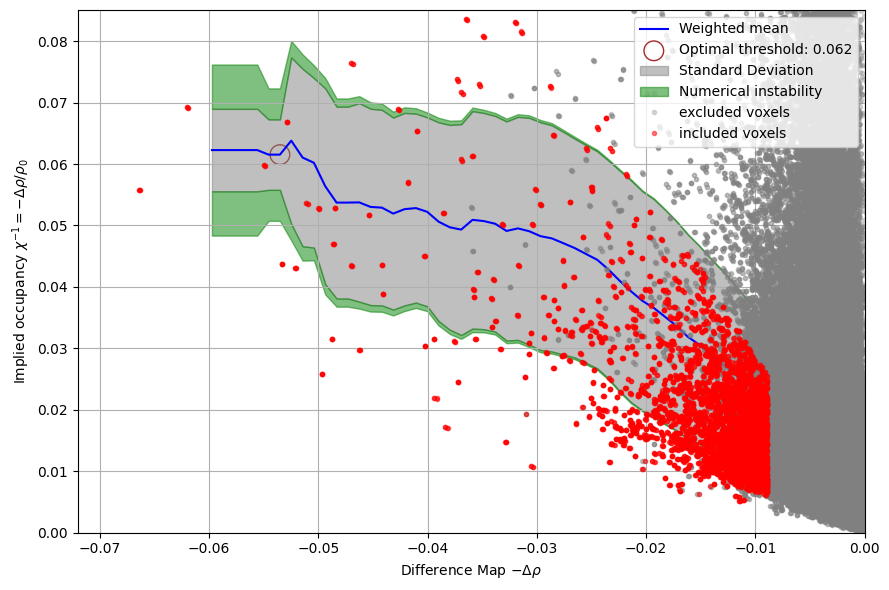

In [4]:
from monster import apply_config, apply_config_rsEGFP2
config = apply_config_rsEGFP2()
config = apply_config()
config["map_processing"]["dark_mean_correction"] = True
config["map_processing"]["diffmap_mean_correction"] = False
config["map_processing"]["diffmap_v2_correction"] = False
unscaled_dark, unscaled_triggered = get_maps(config)
diffmap, map_dark, _ = prepare_maps(unscaled_dark, unscaled_triggered, config)
print(map_dark)

diffmap_np = diffmap.to_3d_numpy_map(map_sampling=config["general"]["map_sampling"])
logger.warning(f"Diffmap Mean: {diffmap_np.mean():.6f}, Std: {diffmap_np.std():.6f}")
inclusion_mask = make_inclusion_mask(diffmap, map_dark, config)
# diffmap_np, map_dark_np = _prepare_maps(
#     diffmap, map_dark, map_dark_comp, info_container, params
# )
fig, ax = plot_extrapolation_estimate(diffmap, map_dark, inclusion_mask, config)
plt.show()
fig.savefig("temp.png")


In [5]:
# diffmap_dark_cor_v2 = diffmap.copy()
# diffmap_dark_cor = diffmap.copy()
# diffmap_dark_cor_v2, diffmap_dark_cor

In [ ]:
import gemmi
from masking import support_from_masker
from processing import autoshift_rsmap


from copy import deepcopy

def prepper( map_dark, diffmap_np, cutoff_threshold, config, inclusion_mask=None):
    map_dark_shifted, dark_offset = autoshift_rsmap(deepcopy(map_dark), config["general"])
    print("dark_offset", dark_offset)


    dark_map_array = map_dark_shifted.to_3d_numpy_map(
        map_sampling=config["general"]["map_sampling"]
    )
    print("map dark mean", dark_map_array.mean())

    no_inclusion_mask = inclusion_mask is None
    if no_inclusion_mask:
        inclusion_mask = np.ones(dark_map_array.shape, dtype=bool)
    cutoff_dark = dark_map_array.mean() + cutoff_threshold * dark_map_array.std()
    only_large_dark = dark_map_array > cutoff_dark
    inclusion_2 = np.logical_and(only_large_dark, inclusion_mask)
    if not no_inclusion_mask:
        print(
            "share excluded from inclusion mask:",
            1 - 1 / np.sum(inclusion_mask) * np.sum(inclusion_2),
        )
    pseudo = -(diffmap_np / dark_map_array).flatten()
    main_mask = inclusion_2
    diff = (-diffmap_np * main_mask).flatten()
    print("map dark mean", dark_map_array.mean())
    return pseudo, diff, cutoff_dark



def moving_average_and_errors(pseudo, diff2, leng_shown=None, number_sym_ops=1, window_size=20):
    leng_shown = len(diff2) if leng_shown is None else leng_shown
    argsorted = np.argsort(diff2)[::-number_sym_ops][:leng_shown]
    pseudo_sort = np.cumsum(pseudo[argsorted]) / (np.arange(len(argsorted))+1)
    # 1. Your existing sorted data
    sorted_vals = pseudo[argsorted]
    # 1. Calculate cumulative sums
    cum_sum = np.insert(np.cumsum(sorted_vals), 0, 0)
    cum_sum_sq = np.insert(np.cumsum(sorted_vals**2), 0, 0)
    
    # 2. Use slice subtraction to get sums for each window
    # This replaces your 'for' loop entirely
    window_sum = cum_sum[window_size:] - cum_sum[:-window_size]
    window_sum_sq = cum_sum_sq[window_size:] - cum_sum_sq[:-window_size]
    
    # 3. Calculate Mean and Variance
    mov_avg = window_sum / window_size
    # Variance formula: E[X^2] - (E[X])^2
    mov_var = (window_sum_sq / window_size) - (mov_avg**2)

    mov_avg_v2 = np.convolve(sorted_vals, np.ones(window_size)/window_size, mode='valid')
    
    # Use np.maximum to handle precision errors before sqrt
    mov_std = np.sqrt(np.maximum(mov_var, 0))
    print("mov_std", mov_std)
    pseudo_std = mov_std
    pseudo_ste = pseudo_std/np.sqrt(window_size)
    bias_term = [np.abs(pseudo_sort[i] - pseudo_sort[i//2]) for i in range(len(pseudo_sort))]
    
    return {
        "pseudo_sort": mov_avg,
        "pseudo_sort_v2": mov_avg_v2,
        "pseudo_std": pseudo_std,
        "pseudo_ste": pseudo_ste,
        "bias_term": bias_term,
        "diff_sorted": diff2[argsorted][window_size-1:],
        "pseudo_std": pseudo_std
    }

def cummean_and_errors(pseudo, diff2, leng_shown=None, number_sym_ops=1):
    leng_shown = len(diff2) if leng_shown is None else leng_shown
    argsorted = np.argsort(diff2)[::-number_sym_ops][:leng_shown]
    pseudo_sort = np.cumsum(pseudo[argsorted]) / (np.arange(len(argsorted))+1)
    # 1. Your existing sorted data
    sorted_vals = pseudo[argsorted]
    weights = diff2[argsorted]
    cum_mean = np.cumsum(sorted_vals) / (np.arange(len(sorted_vals)) + 1)
    cum_weighted = np.cumsum(sorted_vals*weights) / (np.cumsum(weights) + 1e-8)
    cum_mean_sq = np.cumsum(sorted_vals**2) / (np.arange(len(sorted_vals)) + 1)

    # 4. Cumulative standard deviation
    # We use np.maximum to avoid tiny negative numbers due to floating point error
    cum_std = np.sqrt(np.maximum(cum_mean_sq - cum_mean**2, 0))
    pseudo_std = cum_std
    pseudo_ste = pseudo_std/np.sqrt(np.arange(1,len(argsorted)+1))*2
    bias_term = [np.abs(pseudo_sort[i] - pseudo_sort[i//2]) for i in range(len(pseudo_sort))]
    return {
        "pseudo_sort": pseudo_sort,
        "pseudo_weighted": cum_weighted,
        "pseudo_ste": pseudo_ste,
        "bias_term": bias_term,
        "diff_sorted": diff2[argsorted],
        "pseudo_std": pseudo_std
    }
def make_plot_v3(stats, cummean_dict, std_cutoff = 3, solvent_density = 0.4, ax=None):
    marker = "."
    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = ax.get_figure()

    ax.plot(
        stats["diffmap_masked"],
        stats["pseudo_occupancy"],
        label="included voxels",
        marker=marker,
        linestyle="",
        alpha=0.5,
    )
    ax.fill_between(
            -cummean_dict['diff_sorted'],
            cummean_dict['pseudo_sort'] - cummean_dict['pseudo_std'],
            cummean_dict['pseudo_sort'] + cummean_dict['pseudo_std'],
            color='grey',
            alpha=0.2,
        )
    thresh_line = cummean_dict["diff_sorted"]/solvent_density
    average_distance_mask = cummean_dict['pseudo_sort'] + std_cutoff*cummean_dict['pseudo_std'] > thresh_line
    inclusion_index = np.where(average_distance_mask)[0][0]
    plt.plot([-cummean_dict["diff_sorted"][inclusion_index],]*2, [0, thresh_line[inclusion_index]], 'r--', label="Diffmap Cutoff")
    plt.plot([-cummean_dict["diff_sorted"][0],0], [thresh_line[0],0], 'r--', label="Reference Density Cutoff = Solvent")
    ax.plot(-cummean_dict['diff_sorted'], cummean_dict['pseudo_sort'], color='blue')
    ax.set_xlim(np.min(stats["diffmap_masked"])*1.1, 0.0)
    ymax = (cummean_dict['pseudo_sort'] + std_cutoff*2*cummean_dict['pseudo_std'])[inclusion_index]
    ax.set_ylim(0.0, ymax)
    ax.grid()
    ax.legend()
    return fig, ax

def make_plot(
    cummean_dict,
    cutoff_dark,
    x_axis_type= "voxel_count", # "diff_value"
    add_noise_plots=False,
    ax = None
):
    pseudo_sort, pseudo_ste, bias_term, diff_sorted, pseudo_std = (
        cummean_dict["pseudo_sort"],
        cummean_dict["pseudo_ste"],
        cummean_dict["bias_term"],
        cummean_dict["diff_sorted"],
        cummean_dict["pseudo_std"],
    )
    if x_axis_type == "voxel_count":
        x_axis_values = np.arange(len(pseudo_sort))
        xlabel = "# Voxels"
    elif x_axis_type == "diff_value":   
        x_axis_values = -diff_sorted
        xlabel = "Diffmap Values"
    else:
        raise ValueError(f"Unknown x_axis_type: {x_axis_type}")

    cutoffline_indexed = -diff_sorted/cutoff_dark
    max_pseudo = np.min(pseudo_sort + pseudo_std)
    print("Max Pseudo:", max_pseudo)
    cutoffline_below = cutoffline_indexed < max_pseudo
    # cutoffline_above = ~cutoffline_below
    idx = np.argmax(cutoffline_below)
    left, bottom, width, height = (np.min(x_axis_values), 0., np.abs(x_axis_values[idx]-np.min(x_axis_values)), max_pseudo)
    left = float(left)
    print(left, bottom, width, height, idx, (pseudo_sort + pseudo_ste)[idx])
    
    rect = plt.Rectangle((left, bottom), width, height,
                        facecolor="black", alpha=0.1)

    if ax is not None:
        fig = ax.get_figure()
    elif add_noise_plots:
        fig, axs = plt.subplots(1,2, figsize=(12,6))
        ax, ax2 = axs
        ax2.plot(x_axis_values, pseudo_ste, label='Pseudo Standard Error', color='red', alpha=0.5)
        ax2.plot(x_axis_values, bias_term, label='Bias Term: |F(N) -F(N/2)| ', color='orange', alpha=0.5)
        ax2.set_xlabel(xlabel)
        ax2.legend()

    else:
        fig, ax = plt.subplots(figsize=(6,6))
    ax.add_patch(rect)
    ax.fill_between(
        x_axis_values,
        pseudo_sort - pseudo_ste,
        pseudo_sort + pseudo_ste,
        color='blue',
        alpha=0.2,
    )
    pseudo_masked = pseudo_sort[idx//10:idx+1]
    pseudo_label = 'Cumulative Mean \nPseudo-Occupancy'
    pseudo_label += f'\nMean: {pseudo_sort[idx]:.4f}'
    pseudo_label += f'\nStandard Error: {pseudo_ste[idx]:.4f} ({pseudo_ste[idx]/pseudo_sort[idx]:.2%})'
    drift_error = pseudo_masked[0] - pseudo_masked[-1]
    pseudo_label += f'\nDrift Error: {drift_error:.4f} ({drift_error/pseudo_sort[idx]:.2%})'
    ax.plot(x_axis_values, pseudo_sort, label=pseudo_label, color='blue')

    # ax.plot(x_axis_values, cutoffline_indexed, label='Diffmap / Cutoff_dark', color='red', )
    # ax.plot(x_axis_values[cutoffline_below], cutoffline_indexed[cutoffline_below], label='Diffmap / Cutoff_dark(below)', color='orange', alpha=0.5)
    # ax.plot(x_axis_values[cutoffline_above], cutoffline_indexed[cutoffline_above], label='Diffmap / Cutoff_dark(above)', color='orange', alpha=0.5)

    # axi = ax2.twinx()
        # ax2.set_yscale('log')
    ax.set_ylabel("Pseudo-Occupancy")
    ax.set_xlabel(xlabel)
    ax.legend()
    ax.set_ylim(0,None)
    # limit = [0,None] if x_axis_values[1]>=0 else [None,0]
    # ax.set_xlim(limit)
    ax.grid()
    # ax.set_ylim(0,0.2)
    title = "Cumulative Mean Pseudo-Occupancy with Errors"
    fig.suptitle(title)
    return fig, ax

def another_plot(stats, inclusion_mask_v1, inclusion_mask_v2, diffmap_np, map_dark_np, cummean_dict, movmean_dict, cutoffs):
    std_cutoff = 3
    dark_thresh = 0.4
    marker = "."
    # Note: X-axis is pseudo_occupancy (Occupancy), Y-axis is -DifferenceMap
    fig, ax = plt.subplots()
    ax.plot(
        stats["diffmap_masked"],
        stats["pseudo_occupancy"],
        label="included voxels",
        marker=marker,
        linestyle="",
        alpha=0.5,
    )

    pseudo_occupancy = -diffmap_np / map_dark_np
    inclusion_mask_intersection = np.logical_and(inclusion_mask_v1,~inclusion_mask_v2)
    inclusion_mask_not = ~inclusion_mask_v1

    ax.plot(
        diffmap_np[inclusion_mask_intersection],
        pseudo_occupancy[inclusion_mask_intersection],
        marker=".",
        linestyle="",
        label="excluded voxels",
        alpha=0.3,
    )
    ax.plot(
        diffmap_np[inclusion_mask_not],
        pseudo_occupancy[inclusion_mask_not],
        marker=".",
        linestyle="",
        label="excluded voxels",
        alpha=0.3,
    )

    # ax.fill_between(
    #         -movmean_dict['diff_sorted'],
    #         movmean_dict['pseudo_sort_v2'] - movmean_dict['pseudo_std'],
    #         movmean_dict['pseudo_sort_v2'] + movmean_dict['pseudo_std'],
    #         color='green',
    #         alpha=0.2,
    #     )
    # ax.fill_between(
    #         -cummean_dict['diff_sorted'],
    #         cummean_dict['pseudo_sort'] - cummean_dict['pseudo_ste'],
    #         cummean_dict['pseudo_sort'] + cummean_dict['pseudo_ste'],
    #         color='blue',
    #         alpha=0.2,
    #     )
    ax.fill_between(
            -cummean_dict['diff_sorted'],
            cummean_dict['pseudo_sort'] - cummean_dict['pseudo_std'],
            cummean_dict['pseudo_sort'] + cummean_dict['pseudo_std'],
            color='grey',
            alpha=0.2,
        )
    thresh_line = cummean_dict["diff_sorted"]/dark_thresh
    average_distance_mask = cummean_dict['pseudo_sort'] + std_cutoff*cummean_dict['pseudo_std'] > thresh_line
    crossings = np.where(average_distance_mask)[0][0]
    print('hey')
    print(np.where(average_distance_mask))
    thresh_diff = cummean_dict["diff_sorted"][crossings]
    print(thresh_diff)

    plt.plot([-cummean_dict["diff_sorted"][crossings],]*2, [0, thresh_line[crossings]], 'r--')
    

    #     pseudo_masked = pseudo_sort[idx//10:idx+1]
    #     pseudo_label = 'Cumulative Mean \nPseudo-Occupancy'
    #     pseudo_label += f'\nMean: {pseudo_sort[idx]:.4f}'
    #     pseudo_label += f'\nStandard Error: {pseudo_ste[idx]:.4f} ({pseudo_ste[idx]/pseudo_sort[idx]:.2%})'
    #     drift_error = pseudo_masked[0] - pseudo_masked[-1]
    #     pseudo_label += f'\nDrift Error: {drift_error:.4f} ({drift_error/pseudo_sort[idx]:.2%})'
    ax.plot(-cummean_dict['diff_sorted'], cummean_dict['pseudo_sort'], color='blue')
    ax.plot(-cummean_dict['diff_sorted'], cummean_dict["pseudo_weighted"], color='orange')
    ax.plot(-movmean_dict['diff_sorted'], movmean_dict['pseudo_sort'], color='green')
    ax.plot(-movmean_dict['diff_sorted'], movmean_dict['pseudo_sort_v2'], color='purple')

    #     # ax.plot(x_axis_values, cutoffline_indexed, label='Diffmap / Cutoff_dark', color='red', )
    #     # ax.plot(x_axis_values[cutoffline_below], cutoffline_indexed[cutoffline_below], label='Diffmap / Cutoff_dark(below)', color='orange', alpha=0.5)
    #     # ax.plot(x_axis_values[cutoffline_above], cutoffline_indexed[cutoffline_above], label='Diffmap / Cutoff_dark(above)', color='orange', alpha=0.5)

    #     # axi = ax2.twinx()
    #         # ax2.set_yscale('log')
    #     ax.set_ylabel("Pseudo-Occupancy")
    #     ax.set_xlabel(xlabel)
    #     ax.legend()
    #     ax.set_ylim(0,None)
    #     # limit = [0,None] if x_axis_values[1]>=0 else [None,0]
    #     # ax.set_xlim(limit)
    #     ax.grid()
    #     # ax.set_ylim(0,0.2)
    #     title = "Cumulative Mean Pseudo-Occupancy with Errors"
    #     fig.suptitle(title)
    #     return fig, ax


    # # make_plot(cummean_dict, cutoff_dark, x_axis_type="diff_value", add_noise_plots=False, ax=ax)    
    # # make_plot(movmean_dict, -1, x_axis_type="diff_value", add_noise_plots=False, ax=ax)



    diffline = np.linspace(np.min(diffmap_np)*1.1, 0, 5)
    for cutoff in cutoffs:
        ax.plot( diffline,-diffline / cutoff, '--', label='Dark Size Threshold')
    # ax.plot( diffline,-diffline / cutoff_dark_v2, 'g--', label='Dark Size Threshold')
    # # cutoff_dark = map_dark_np.mean()+  map_dark_np.std()* 0.1
    # ax.plot( diffline,-diffline / cutoff_dark, 'g--', label='Dark Size Threshold')
    ax.set_ylim(0, 0.2)
    ax.set_xlim(np.min(stats["diffmap_masked"])*1.1, 0.0)
    ax.grid()
    ax.legend()
    plt.show()







2026-03-04 17:19:14,821: logger: WARNING: Used threshold for posmask: 0.134, found 1921 blobs (masking.py:133)
2026-03-04 17:19:14,828: logger: INFO: Using blobs with more than 5.517894359740814(3 A^3) voxels (masking.py:150)
2026-03-04 17:19:14,829: logger: INFO: Maximum Blob sizes found: 411 (masking.py:151)
2026-03-04 17:19:15,226: logger: INFO: Applying blocking radius of 1.5 A around positive density regions creating a mask of shape (5, 5, 5), considering a total of 26 voxels (control via 'blocking_radius' parameter) (masking.py:182)
2026-03-04 17:19:15,337: logger: INFO: Excluding 178 (1.23%) voxels from mask due to positive density within 1.5 A and above the 95 percentile (control via 'blocking_radius' and 'blocking_percentile' parameters) (masking.py:196)
2026-03-04 17:19:15,382: logger: INFO: Excluding an addtional 2477 voxels from mask due to being in solvent (deactivate via 'exclude_solvent' parameter) (masking.py:268)
2026-03-04 17:19:15,480: logger: WARNING: Used threshold

mov_std [0.01606162 0.01605722 0.01605261 ... 0.32742876 0.32754892 0.3276592 ]


2026-03-04 17:19:15,832: logger: INFO: Applying blocking radius of 1.5 A around positive density regions creating a mask of shape (5, 5, 5), considering a total of 26 voxels (control via 'blocking_radius' parameter) (masking.py:182)
2026-03-04 17:19:15,940: logger: INFO: Excluding 178 (1.23%) voxels from mask due to positive density within 1.5 A and above the 95 percentile (control via 'blocking_radius' and 'blocking_percentile' parameters) (masking.py:196)
2026-03-04 17:19:15,980: logger: INFO: Excluding an addtional 2477 voxels from mask due to being in solvent (deactivate via 'exclude_solvent' parameter) (masking.py:268)


Max Pseudo: 0.05579198896884918
-0.0663696825504303 0.0 0.0 0.05579198896884918 0 0.05579198896884918


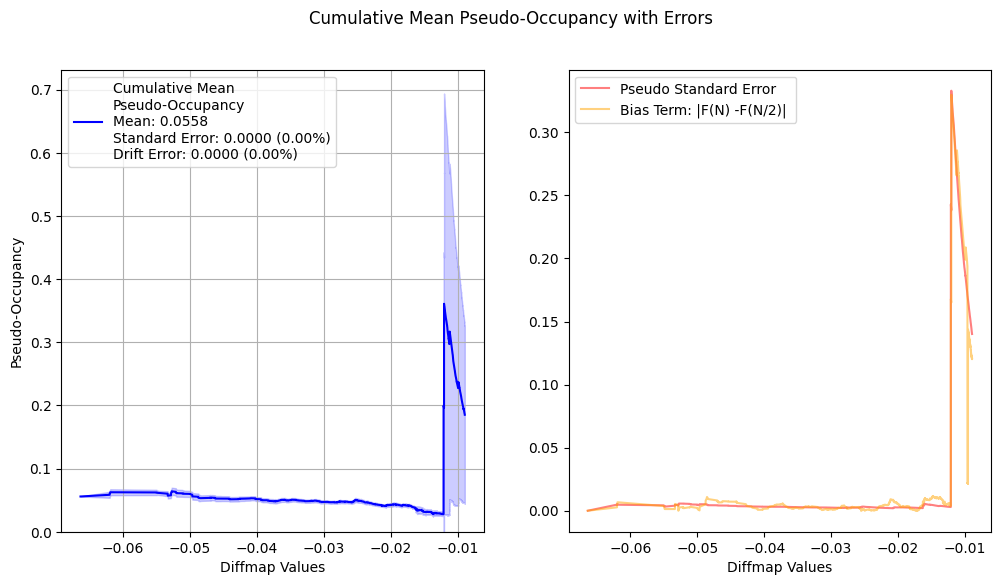

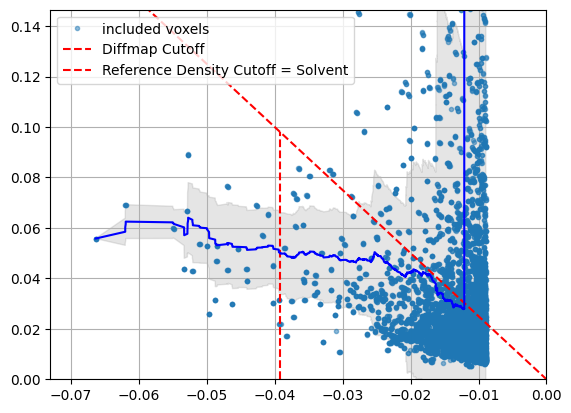

In [ ]:
diffmap_np = diffmap.to_3d_numpy_map(map_sampling=config["general"]["map_sampling"])
map_dark_np = map_dark.to_3d_numpy_map(map_sampling=config["general"]["map_sampling"])

cutoff_thresh_1 = -.0
cutoff_thresh_2 = 0.0
window_size = 50
config['masking']['dark_size_threshold'] = cutoff_thresh_1
cutoff_dark_v1 = map_dark_np.mean()+ config['masking']['dark_size_threshold'] * map_dark_np.std()

if cutoff_dark_v1 < 0:
    raise ValueError(f"Cutoff_dark_v1 is negative: {cutoff_dark_v1}. Please choose a less negative cutoff threshold.")
inclusion_mask_v1 = make_inclusion_mask(diffmap, map_dark, config)
stats_data = _calculate_statistics(diffmap_np, map_dark_np, inclusion_mask_v1)

movmean_dict = moving_average_and_errors(stats_data["pseudo_occupancy"], -stats_data["diffmap_masked"], number_sym_ops=1, window_size=window_size)
config['masking']['dark_size_threshold'] = cutoff_thresh_2
cutoff_dark_v2 = map_dark_np.mean()+ config['masking']['dark_size_threshold'] * map_dark_np.std()

inclusion_mask_v2 = make_inclusion_mask(diffmap, map_dark, config)

stats = _calculate_statistics(diffmap_np, map_dark_np, inclusion_mask_v2)
cummean_dict = cummean_and_errors(stats["pseudo_occupancy"], -stats["diffmap_masked"], number_sym_ops=1)
make_plot_v3(stats,cummean_dict)
make_plot(cummean_dict, cutoff_dark_v2, x_axis_type="diff_value", add_noise_plots=True)
# ax.axvline(-np.percentile(np.abs(diffmap_np),95))

# logger.warning(
#     f"Mean of diffmap_np: {np.mean(diffmap_np)}, Mean of map_dark_np: {np.mean(map_dark_np)}"
# )
# trend_data = _analyze_threshold_trends(
#     stats_data["diffmap_masked"],
#     stats_data["pseudo_occupancy"],
#     stats_data["weight"],
# )
# diffline = np.linspace(-1,0, 100)
# fig, ax = plt.subplots()

# plot_config = config['plot']
# simplify(stats, inclusion_mask_v1, inclusion_mask_v2, diffmap_np, map_dark_np, cummean_dict, movmean_dict, (cutoff_dark_v1, cutoff_dark_v2, 0.3, 0.4))

In [32]:
delta_over_zero = 0.05
delta = 0.02
zero =  delta/delta_over_zero
crossover_point = zero
crossover_point

0.39999999999999997

In [103]:
-diffline /(dark_mean + dark_std * cutoff_thresh_1), -diffline /(dark_mean + dark_std * cutoff_thresh_2)
dark_mean

np.float32(0.31972757)

In [19]:
def get_diffmaps(dark_mean_correction=False, diffmap_mean_correction=False, diffmap_v2_correction=False):
    config = apply_config()
    config["map_processing"]["diffmap_mean_correction"] = diffmap_mean_correction
    config["map_processing"]["dark_mean_correction"] = dark_mean_correction
    config["map_processing"]["diffmap_v2_correction"] = diffmap_v2_correction
    unscaled_dark, unscaled_triggered = get_maps(config)
    diffmap, map_dark, _ = prepare_maps(unscaled_dark, unscaled_triggered, config)

    return diffmap


diffmap_none = get_diffmaps(
    dark_mean_correction=False, 
    diffmap_mean_correction=False, 
    diffmap_v2_correction=False)
diffmap_both = get_diffmaps(
    dark_mean_correction=True, 
    diffmap_mean_correction=True, 
    diffmap_v2_correction=False)
diffmap_v2 = get_diffmaps(
    dark_mean_correction=True, 
    diffmap_mean_correction=True, 
    diffmap_v2_correction=True)


2026-02-18 16:04:45,293: logger: INFO: Imposing high_resolution_limit: 2.6 (processing.py:37)


0 11_100us/100us
1 9_10us/10us
3 7_30ns/30ns
5 3_300ps/300ps
6 10_30us/30us
7 2_3ps/3ps
8 4_1ns/1ns
10 8_1us/1us
13 6_10ns/10ns
14 5_3ns/3ns
/Users/sbielfel/Nextcloud2/time_resolved/data/photolyase/7_30ns/30ns_deposit.mtz


2026-02-18 16:04:47,266: logger: INFO: this is calculate_again True (processing.py:94)
2026-02-18 16:04:47,268: logger: INFO: loading: 0.07, tv_weight: 0.005807665501203384, only_kweighted: False (processing.py:115)


2026-02-18 16:04:47 [info     ] scaling: native --> calculated weight_using_uncertainties=True
2026-02-18 16:04:48 [info     ] scaling: derivative --> calculated weight_using_uncertainties=True
2026-02-18 16:04:48 [info     ] Computing difference map.     
2026-02-18 16:04:48 [info     ]   using fixed                  kparameter=0.07
2026-02-18 16:04:48 [info     ] TV denoising with fixed weight weight=0.005807665501203384
2026-02-18 16:04:50 [info     ] Map TV-denoised with fixed weight final_negentropy=2.94e-01 initial_negentropy=9.97e-03 weight=0.005807665501203384


2026-02-18 16:04:50,591: logger: INFO: diffmap has uncertainties: True (processing.py:157)
2026-02-18 16:04:50,592: logger: INFO: Diffmap zero frequency: 1.7881393432617188e-07 (processing.py:302)
2026-02-18 16:04:50,634: logger: INFO: Imposing high_resolution_limit: 2.6 (processing.py:37)


...

2026-02-18 16:04:59,312: logger: INFO: diffmap has uncertainties: True (processing.py:157)
2026-02-18 16:04:59,313: logger: INFO: Diffmap zero frequency: 0.04890799522399902 (processing.py:302)
2026-02-18 16:04:59,313: logger: WARNING: Diffmap zero frequency: -4122.96875 (processing.py:321)
2026-02-18 16:04:59,355: logger: INFO: Imposing high_resolution_limit: 2.6 (processing.py:37)


0 11_100us/100us
1 9_10us/10us
3 7_30ns/30ns
5 3_300ps/300ps
6 10_30us/30us
7 2_3ps/3ps
8 4_1ns/1ns
10 8_1us/1us
13 6_10ns/10ns
14 5_3ns/3ns
/Users/sbielfel/Nextcloud2/time_resolved/data/photolyase/7_30ns/30ns_deposit.mtz


2026-02-18 16:05:01,239: logger: INFO: this is calculate_again True (processing.py:94)
2026-02-18 16:05:01,240: logger: INFO: loading: 0.07, tv_weight: 0.005807665501203384, only_kweighted: False (processing.py:115)


2026-02-18 16:05:01 [info     ] scaling: native --> calculated weight_using_uncertainties=True
2026-02-18 16:05:02 [info     ] scaling: derivative --> calculated weight_using_uncertainties=True
2026-02-18 16:05:02 [info     ] Computing difference map.     
2026-02-18 16:05:02 [info     ]   using fixed                  kparameter=0.07
2026-02-18 16:05:02 [info     ] TV denoising with fixed weight weight=0.005807665501203384
2026-02-18 16:05:04 [info     ] Map TV-denoised with fixed weight final_negentropy=2.94e-01 initial_negentropy=9.97e-03 weight=0.005807665501203384


2026-02-18 16:05:04,575: logger: INFO: diffmap has uncertainties: True (processing.py:157)
2026-02-18 16:05:04,600: logger: INFO: Diffmap std: 0.001 (processing.py:274)
2026-02-18 16:05:04,602: logger: INFO: diffmap larger voxel count: 0.15520061728395063 (processing.py:275)
2026-02-18 16:05:04,665: logger: INFO: ignore_mask voxel count: 0.5746728395061729 (processing.py:217)
2026-02-18 16:05:04,675: logger: INFO: Shift value 0.31973 corresponds to zero frequency 450570.750 (processing.py:231)
2026-02-18 16:05:04,700: logger: INFO: calculating autoshift for triggered map... with extra mask (processing.py:282)
2026-02-18 16:05:04,766: logger: INFO: ignore_mask voxel count: 0.6968371913580247 (processing.py:217)
2026-02-18 16:05:04,777: logger: INFO: Shift value 0.31680 corresponds to zero frequency 446447.781 (processing.py:231)
2026-02-18 16:05:04,803: logger: INFO: calculating autoshift for triggered map... done (processing.py:286)
2026-02-18 16:05:04,804: logger: INFO: Diffmap zero f

In [30]:
diffmap_dark = get_diffmaps(
    dark_mean_correction=True, 
    diffmap_mean_correction=False, 
    diffmap_v2_correction=False)


2026-01-08 14:47:25,645: logger: INFO: Imposing high_resolution_limit: 2.6 (processing.py:37)


0 11_100us/100us
1 9_10us/10us
3 7_30ns/30ns
5 3_300ps/300ps
6 10_30us/30us
7 2_3ps/3ps
8 4_1ns/1ns
10 8_1us/1us
13 6_10ns/10ns
14 5_3ns/3ns
/Users/sbielfel/Nextcloud2/time_resolved/data/photolyase/7_30ns/30ns_deposit.mtz


2026-01-08 14:47:27,598: logger: INFO: this is calculate_again True (processing.py:88)
2026-01-08 14:47:27,601: logger: INFO: loading: 0.07, tv_weight: 0.005807665501203384, only_kweighted: False (processing.py:109)


2026-01-08 14:47:28 [info     ] scaling: native --> calculated weight_using_uncertainties=True
2026-01-08 14:47:28 [info     ] scaling: derivative --> calculated weight_using_uncertainties=True
2026-01-08 14:47:28 [info     ] Computing difference map.     
2026-01-08 14:47:28 [info     ]   using fixed                  kparameter=0.07
2026-01-08 14:47:28 [info     ] TV denoising with fixed weight weight=0.005807665501203384
2026-01-08 14:47:31 [info     ] Map TV-denoised with fixed weight final_negentropy=2.94e-01 initial_negentropy=9.97e-03 weight=0.005807665501203384


2026-01-08 14:47:31,010: logger: INFO: diffmap has uncertainties: True (processing.py:151)
2026-01-08 14:47:31,036: logger: INFO: Diffmap std: 0.001 (processing.py:260)
2026-01-08 14:47:31,036: logger: INFO: diffmap larger voxel count: 0.15520061728395063 (processing.py:261)
2026-01-08 14:47:31,103: logger: INFO: ignore_mask voxel count: 0.5746728395061729 (processing.py:205)
2026-01-08 14:47:31,113: logger: INFO: Shift value 0.31973 corresponds to zero frequency 450570.750 (processing.py:219)
2026-01-08 14:47:31,138: logger: INFO: calculating autoshift for triggered map... with extra mask (processing.py:270)
2026-01-08 14:47:31,201: logger: INFO: ignore_mask voxel count: 0.6968371913580247 (processing.py:205)
2026-01-08 14:47:31,212: logger: INFO: Shift value 0.31680 corresponds to zero frequency 446447.781 (processing.py:219)
2026-01-08 14:47:31,237: logger: INFO: calculating autoshift for triggered map... done (processing.py:274)
2026-01-08 14:47:31,238: logger: INFO: this is calcul

2026-01-08 14:47:31 [info     ] scaling: native --> calculated weight_using_uncertainties=True
2026-01-08 14:47:32 [info     ] scaling: derivative --> calculated weight_using_uncertainties=True
2026-01-08 14:47:32 [info     ] Computing difference map.     
2026-01-08 14:47:32 [info     ]   using fixed                  kparameter=0.07
2026-01-08 14:47:32 [info     ] TV denoising with fixed weight weight=0.005807665501203384
2026-01-08 14:47:34 [info     ] Map TV-denoised with fixed weight final_negentropy=1.55e-01 initial_negentropy=5.26e-03 weight=0.005807665501203384


2026-01-08 14:47:34,693: logger: INFO: diffmap has uncertainties: True (processing.py:151)
2026-01-08 14:47:34,694: logger: INFO: Diffmap zero frequency: 0.04890799522399902 (processing.py:286)


In [25]:
k = 25
# np.partition(np.abs(diffmap_none - diffmap_both)["F"], -k)[-k:]
np.partition(np.abs(diffmap_v2 - diffmap_both)["F"], -k)[-k:]
# diffmap_v2 - diffmap_both
# diffmap_v2 - diffmap_none
# np.partition(np.abs(diffmap_v2 - diffmap_none)["F"], -5)[-5:] 

array([34.642048, 34.962906, 35.05324 , 40.479927, 36.182526, 36.78347 ,
       38.39808 , 35.71168 , 36.32284 , 42.121384, 44.25109 , 35.892406,
       38.326313, 37.14542 , 36.884373, 37.496983, 39.595116, 36.085133,
       45.088154, 41.269215, 39.29129 , 38.231754, 37.64419 , 36.360794,
       42.181126], dtype=float32)

In [34]:

np.partition((diffmap_both)["F"], -k)[-k:], np.partition((diffmap_v2)["F"], -k)[-k:]

(array([46.260662, 46.314034, 46.346474, 46.459118, 46.56161 , 47.057083,
        47.792854, 48.862274, 49.40094 , 48.294502, 49.02378 , 47.64422 ,
        50.620403, 47.720734, 47.409863, 47.769306, 48.896614, 47.313137,
        49.71831 , 49.77447 , 49.88201 , 47.444435, 47.17728 , 49.74148 ,
        51.6721  ], dtype=float32),
 array([19.560114, 19.704008, 19.799198, 23.423077, 24.657536, 20.885685,
        20.136642, 22.606974, 21.08106 , 24.631668, 25.147888, 19.983503,
        22.194738, 20.360807, 25.374449, 21.623962, 28.080046, 21.369673,
        21.34885 , 22.547691, 22.941494, 22.452763, 20.71508 , 21.223156,
        21.363565], dtype=float32))

interactive(children=(IntSlider(value=0, description='f0', max=89), Output()), _dom_classes=('widget-interact'…

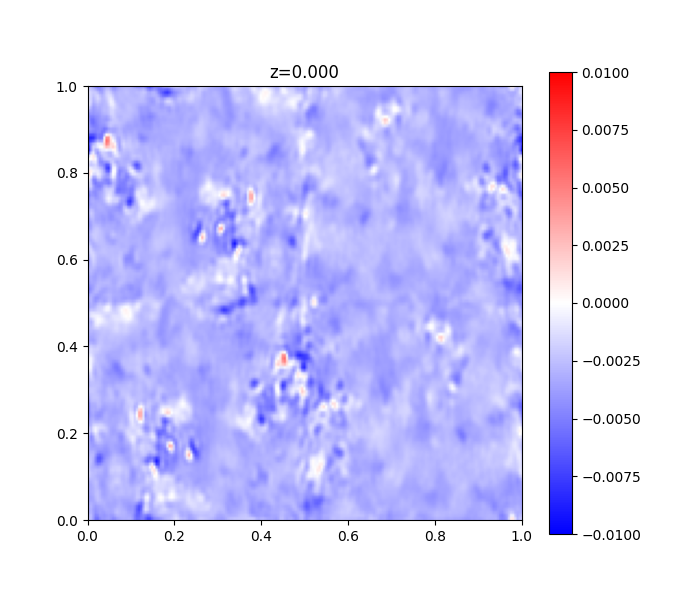

interactive(children=(IntSlider(value=0, description='f0', max=89), Output()), _dom_classes=('widget-interact'…

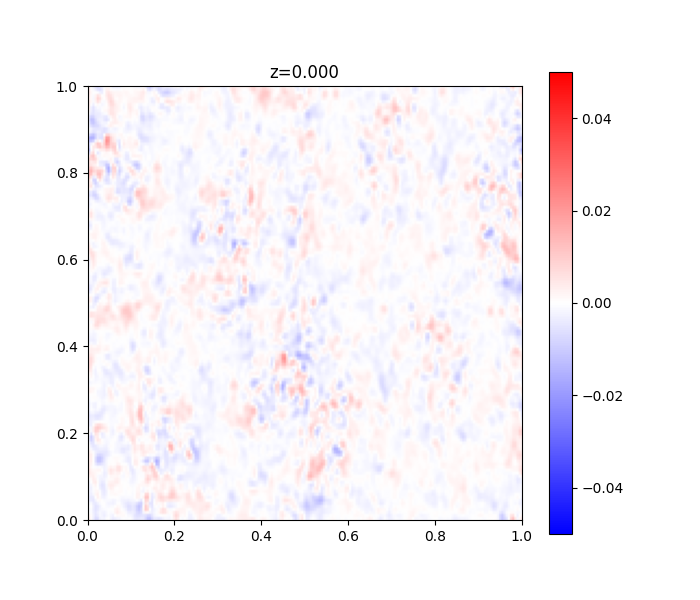

In [54]:
from plotting3d import slice_3d
%matplotlib widget
diffmap_v2_np = diffmap_v2.to_3d_numpy_map(map_sampling=config["general"]["map_sampling"])
diffmap_dark_np = diffmap_dark.to_3d_numpy_map(map_sampling=config["general"]["map_sampling"])
diffmap_both_np = diffmap_both.to_3d_numpy_map(map_sampling=config["general"]["map_sampling"])
imkwargs= {"cmap":"bwr", "vmax":0.05, "vmin":-0.05}
imkwargs2= {"cmap":"bwr", "vmax":0.01, "vmin":-0.01}
_ = slice_3d(diffmap_v2_np, imkwargs=imkwargs2)
plt.show()
_ = slice_3d(diffmap_dark_np, imkwargs=imkwargs)
plt.show()
# _ = slice_3d(diffmap_both_np, imkwargs=imkwargs)

interactive(children=(IntSlider(value=0, description='f0', max=89), Output()), _dom_classes=('widget-interact'…

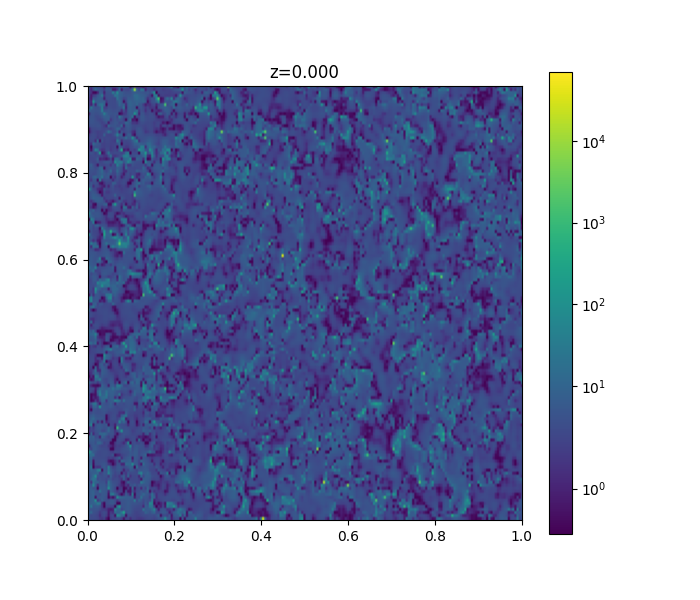

In [53]:
diffmap_none_np = diffmap_none.to_3d_numpy_map(map_sampling=config["general"]["map_sampling"])

_ = slice_3d(np.abs(diffmap_dark_np)/np.abs(diffmap_none_np), imkwargs = dict(norm="symlog"))
plt.show()


In [ ]:
=a1))
plt.show()
